<a href="https://colab.research.google.com/github/Alaa-f-Abdalaal/Machine-Projectss/blob/main/classifcation_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-learn xgboost imbalanced-learn sentence-transformers -q

In [2]:
# 2. IMPORTS
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler

from sentence_transformers import SentenceTransformer
from scipy.sparse import hstack, csr_matrix

In [3]:
# 3. LOAD DATA
# ==============================
df = pd.read_excel('/content/Awnn_feature_engineering (1).xlsx')

drop_cols = ['name','national_id','phone','city','neighborhood','recommended_org']
df = df.drop(columns=drop_cols, errors='ignore')

df = df[df['assistance_type'] != 'unknown'].reset_index(drop=True)
df['request_text'] = df['request_text'].astype(str)

print("Class counts:\n", df['assistance_type'].value_counts())

Class counts:
 assistance_type
medical                 15296
food                    11441
financial               11332
education                7669
housing                  7494
disability_equipment     3756
Name: count, dtype: int64


In [4]:
# 4. FEATURES
# ==============================
X_text = df['request_text']
y = df['assistance_type']

structured_features = [
    'financial_gap','hardship_score','income_stability','family_size','children_ratio',
    'economic_pressure','debt_to_income_ratio','remaining_income','is_deficit','critical_case'
]
X_structured = df[structured_features]

In [5]:
# 5. TRAIN-TEST SPLIT
# ==============================
X_text_train, X_text_test, X_struct_train, X_struct_test, y_train, y_test = train_test_split(
    X_text, X_structured, y, test_size=0.2, random_state=42, stratify=y
)


In [6]:
# 6. OVERSAMPLING للفئات القليلة
# ==============================
X_train_combined = X_struct_train.copy()
X_train_combined['request_text'] = X_text_train.values

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train_combined, y_train)

X_text_train_res = X_resampled['request_text']
X_struct_train_res = X_resampled[structured_features]
y_train_res = y_resampled

In [7]:
# 7. SENTENCE EMBEDDINGS
# ==============================
# نموذج جاهز صغير وسريع: all-MiniLM-L6-v2
embedder = SentenceTransformer('all-MiniLM-L6-v2')

X_text_train_emb = embedder.encode(X_text_train_res.tolist(), convert_to_numpy=True)
X_text_test_emb = embedder.encode(X_text_test.tolist(), convert_to_numpy=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
# 8. SCALE STRUCTURED FEATURES
# ==============================
scaler = StandardScaler()
X_struct_train_scaled = scaler.fit_transform(X_struct_train_res)
X_struct_test_scaled = scaler.transform(X_struct_test)


In [9]:
# 9. COMBINE EMBEDDINGS + STRUCTURED FEATURES
# ==============================
X_train_final = np.hstack([X_text_train_emb, X_struct_train_scaled])
X_test_final = np.hstack([X_text_test_emb, X_struct_test_scaled])

In [10]:
# 10. ENCODE LABELS
# ==============================
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_res)
y_test_enc = le.transform(y_test)


In [11]:
# 11. CLASS WEIGHTS
# ==============================
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_enc), y=y_train_enc)
sample_weights = np.array([class_weights[i] for i in y_train_enc])


In [12]:
# 12. XGBOOST MODEL
# ==============================
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    objective='multi:softprob'
)

xgb.fit(X_train_final, y_train_enc, sample_weight=sample_weights)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

Accuracy: 0.9589401649412178
Macro F1: 0.9586153236329897

Classification Report:

                      precision    recall  f1-score   support

disability_equipment       0.96      0.95      0.96       751
           education       0.96      0.95      0.96      1534
           financial       0.96      0.96      0.96      2267
                food       0.95      0.97      0.96      2288
             housing       0.96      0.96      0.96      1499
             medical       0.96      0.96      0.96      3059

            accuracy                           0.96     11398
           macro avg       0.96      0.96      0.96     11398
        weighted avg       0.96      0.96      0.96     11398



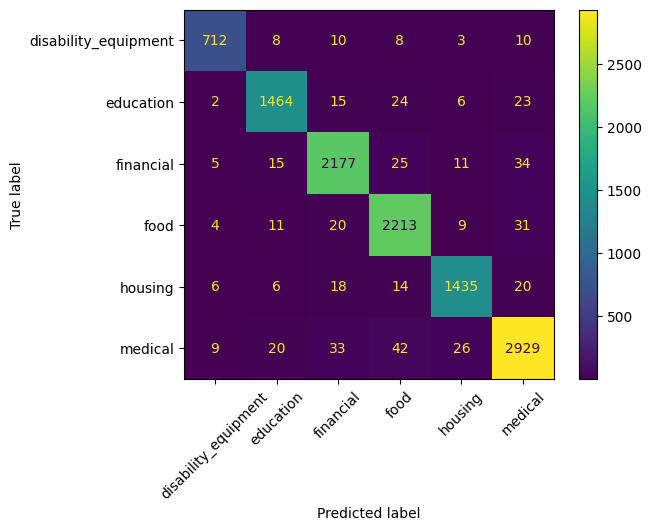

In [13]:
# 13. EVALUATION
# ==============================
y_pred = xgb.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test_enc, y_pred))
print("Macro F1:", f1_score(y_test_enc, y_pred, average='macro'))

print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(y_test_enc, y_pred, display_labels=le.classes_)
plt.xticks(rotation=45)
plt.show()

In [14]:
# 14. PREDICTION FUNCTION
# ==============================
def predict_case(text, structured_values):
    text_emb = embedder.encode([str(text)], convert_to_numpy=True)
    structured_df = np.array([structured_values])
    structured_scaled = scaler.transform(structured_df)
    final_input = np.hstack([text_emb, structured_scaled])
    pred_prob = xgb.predict_proba(final_input)
    pred_class = np.argmax(pred_prob, axis=1)
    return le.classes_[pred_class[0]], pred_prob

In [15]:
# 15. TEST EXAMPLES
# ==============================
sample_index = 7
print("True label:", df['assistance_type'].iloc[sample_index])
pred, prob = predict_case(df['request_text'].iloc[sample_index], df[structured_features].iloc[sample_index].tolist())
print("Prediction:", pred)
print("Probabilities:", prob)

examples = [
    ("I need medical treatment urgently", [4000,0.9,0.2,5,0.6,0.7,0.5,-800,1,1]),
    ("I cannot pay school fees", [1000,0.4,0.7,3,0.4,0.3,0.2,200,0,0]),
    ("I need food support", [1500,0.5,0.6,4,0.5,0.4,0.3,-100,1,0]),
    ("أنا محتاج علاج طبي بشكل عاجل", [4000,0.9,0.2,5,0.6,0.7,0.5,800,1,1])
]

for text, struct_vals in examples:
    pred, prob = predict_case(text, struct_vals)
    print(f"Text: {text}\nPrediction: {pred}\nProbabilities: {prob}\n")

True label: medical
Prediction: medical
Probabilities: [[6.7038531e-04 2.6797250e-04 1.9982131e-04 2.0071170e-04 4.0732027e-04
  9.9825376e-01]]
Text: I need medical treatment urgently
Prediction: food
Probabilities: [[0.03001685 0.31399778 0.00740832 0.38281178 0.0438442  0.22192115]]

Text: I cannot pay school fees
Prediction: food
Probabilities: [[0.02536888 0.12937519 0.12156469 0.5055501  0.15624575 0.06189535]]

Text: I need food support
Prediction: education
Probabilities: [[0.01461642 0.5664355  0.02333525 0.31512582 0.0279447  0.05254233]]

Text: أنا محتاج علاج طبي بشكل عاجل
Prediction: food
Probabilities: [[0.00709959 0.13774382 0.01506989 0.4363902  0.00802402 0.39567253]]



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
